# Evaluate an LSST Y1 covariance with CoCoA

This notebook computes the **Gaussian cosmic-shear covariance of one source
bin**, with rows ordered as all $\xi_+$ angles followed by all $\xi_-$ angles.
It uses LSST Y1's five lens and five source distributions. The small example
makes numerical refinement visible without starting a full survey calculation.

The shared Python algorithms live in `cosmolike_notebook_utils.covariance`;
`covariance/lsst_y1_covariance.py` supplies this project's survey choices.
C performs the quadrature and projection with SIMDe and OpenMP. Python can
request rectangular blocks; no C routine starts MPI processes.

**Physics scope:** nonlinear matter power, Limber angular spectra, full-sky
bin-averaged spin transforms, Gaussian $f_{\rm sky}$ signal covariance and
spherical-cap pair noise. IA and magnification are zero. This example does
not include SSC, cNG, non-Limber spectra or the actual survey footprint.
It does not replace the likelihood's supplied covariance.

Activate the Cocoa environment and follow the main README's setup before
starting Jupyter. Build the LSST Y1 interface after updating the core.


In [1]:
import os
from pathlib import Path
import sys

# Set the BLAS policy before importing numerical libraries. OpenMP workers
# belong to the explicit C loops, not to nested BLAS matrix operations.
os.environ["OPENBLAS_NUM_THREADS"] = "1"
root = Path(os.environ["ROOTDIR"])
project = root/"projects/lsst_y1"
sys.path.insert(0, str(root/"external_modules/code/cosmolike_core"))
sys.path.insert(0, str(root/"external_modules/code/CAMB"))
sys.path.insert(0, str(project/"interface"))
sys.path.insert(0, str(project/"covariance"))

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib
import numpy as np
from threadpoolctl import threadpool_limits
import cosmolike_lsst_y1_interface as ci
import lsst_y1_covariance as survey
from cosmolike_notebook_utils import covariance as cov
from cosmolike_notebook_utils import plot_covariances as pcov

blas_limit = threadpool_limits(limits=1, user_api="blas")
ci.set_omp_threads(n=8)

# Figure appearance belongs to the notebook, not the shared plotters.
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'


## Survey and numerical choices

The [LSST DESC Science Requirements Document](https://arxiv.org/abs/1809.01669)
guides the illustrative area ($12{,}300\,\mathrm{deg}^2$), total lens/source
number densities ($18/10\,\mathrm{arcmin}^{-2}$) and per-component ellipticity
dispersion ($0.26$). Here each total is **equally divided among five bins**.
That allocation is an explicit forecast assumption: normalized $n(z)$ columns
do not contain the number densities. The fiducial has massless neutrinos,
zero photo-z shifts and zero IA, rather than the frozen likelihood's parameters.

Angular bins match the project: 26 bins from 2.5 to 900 arcmin. The multipole,
radial and mask cutoffs are controlled together by one `accuracy_boost`.
Use 1, 2, 4 or 8; 1 is a pilot and 8 is an expensive numerical stress setting.
The resolved values remain inspectable in `settings`. These are not certified
accuracy labels for survey inference. The next calculation raises the boost
from 1 through 2 to 4 while keeping the physical model fixed. CAMB accuracy is separate.


In [2]:
settings = survey.configuration(accuracy_boost=1)
camb_tables = survey.initialize(interface=ci, settings=settings)
ci.set_omp_threads(n=8)
result = survey.shear_gaussian(interface=ci, settings=settings)

modes = cov.covariance_modes(matrix=result["gaussian"])
print("Source bins:", result["snapshot"]["nsource"])
print("Covariance shape:", result["gaussian"].shape)
print("Minimum correlation eigenvalue:",
      modes["correlation_eigenvalues"][0])
print("Positive definite:", modes["positive_definite"])


Source bins: 5
Covariance shape: (52, 52)
Minimum correlation eigenvalue: 0.3376751678977233
Positive definite: True


## Refine the numerical integration

A positive diagonal is not sufficient: a covariance must give nonnegative
variance to **every** linear combination of measurements. We inspect its
correlation eigenvalues without clipping or adding a diagonal correction.

The generalized eigenvalues of $C v=\lambda C_{\rm ref}v$ bound the variance
ratio in any direction. They are useful diagnostics, but survey acceptance
must ultimately check parameter errors and the marginalized Fisher Figure of
Merit. The highest tested boost is the **comparison reference**, not automatically
a converged source of truth. The table below compares boosts 1, 2 and 4.
Increase the list to include 8 when ready for the stronger, more expensive
check. A reference compared to itself has zero change by construction.


In [3]:
# Only accuracy_boost changes. Reuse the same installed CAMB tables,
# survey, angular bins and cosmology throughout this comparison.
boosts = [1, 2, 4]
results_by_boost = {}
for boost in boosts:
    if boost == settings["accuracy_boost"]:
        results_by_boost[boost] = result
        continue
    boosted_settings = dict(settings)
    boosted_settings.update(cov.covariance_accuracy(accuracy_boost=boost))
    results_by_boost[boost] = survey.shear_gaussian(
        interface=ci, settings=boosted_settings
    )

reference_boost = boosts[-1]
reference = results_by_boost[reference_boost]
print("Boost  Max variance-ratio change  Max error-bar change  Min corr eigenvalue")
for boost in boosts:
    matrix = results_by_boost[boost]["gaussian"]
    comparison = cov.compare_covariances(
        matrix=matrix, reference=reference["gaussian"]
    )
    error_ratio = np.sqrt(np.diag(matrix)/np.diag(reference["gaussian"]))
    max_error_change = np.max(np.abs(error_ratio-1.0))
    modes = cov.covariance_modes(matrix=matrix)
    print(f"{boost:5d}  "
          f"{comparison['maximum_fractional_variance_change']:25.6e}  "
          f"{max_error_change:20.6e}  "
          f"{modes['correlation_eigenvalues'][0]:19.6e}")


Boost  Max variance-ratio change  Max error-bar change  Min corr eigenvalue
    1               1.043470e-04          2.410347e-05         3.376752e-01
    2               1.102522e-05          2.644153e-06         3.376790e-01
    4               2.220446e-15          0.000000e+00         3.376793e-01


## Correlations and component fractions

The split-triangle layout follows [Friedrich et al. (2021), Fig. 6](https://arxiv.org/abs/2012.08568):
the lower triangle shows boost 1 and the upper triangle boost 4.
Each is normalized by its own diagonal.

The maps-plus-histogram layout follows [Barreira, Krause & Schmidt (2018),
Fig. 1](https://arxiv.org/abs/1807.04266). Their figure compares SSC and cNG
fractions. Here the same plotting function compares the **actual Gaussian
pieces computed above**: signal plus mixed noise, and pure pair noise.
Pass named G, SSC and cNG matrices when those components are available;
the plotter never invents or rescales a missing component.


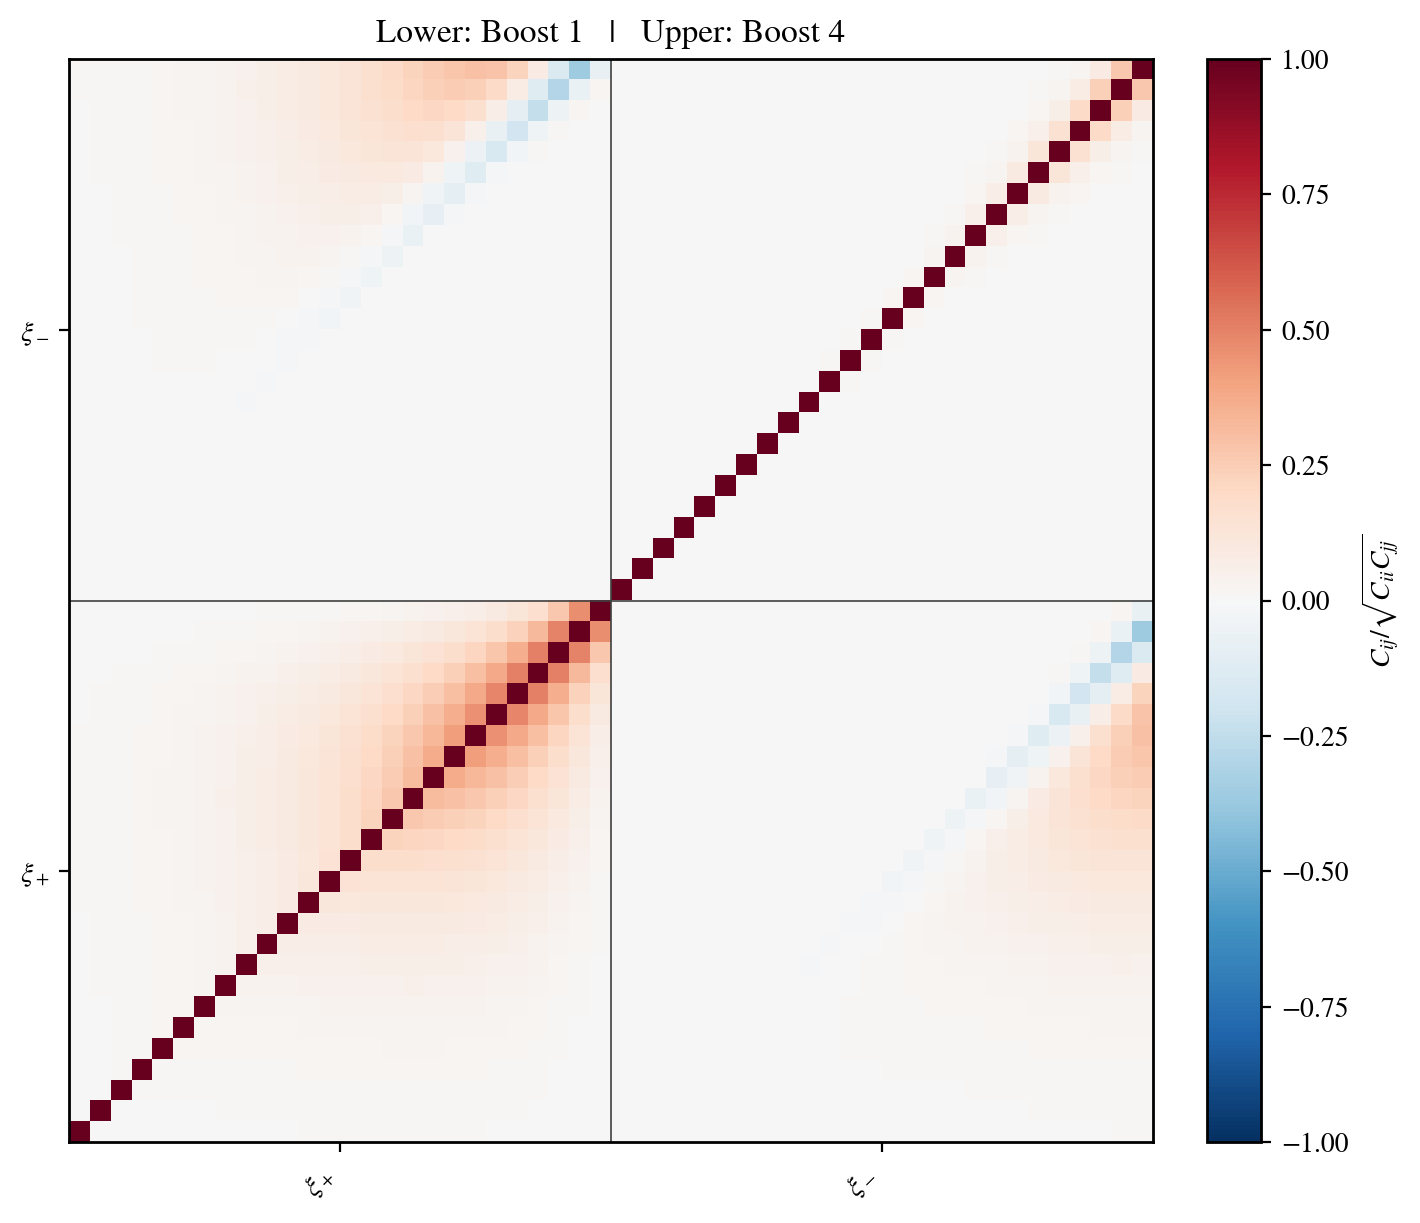

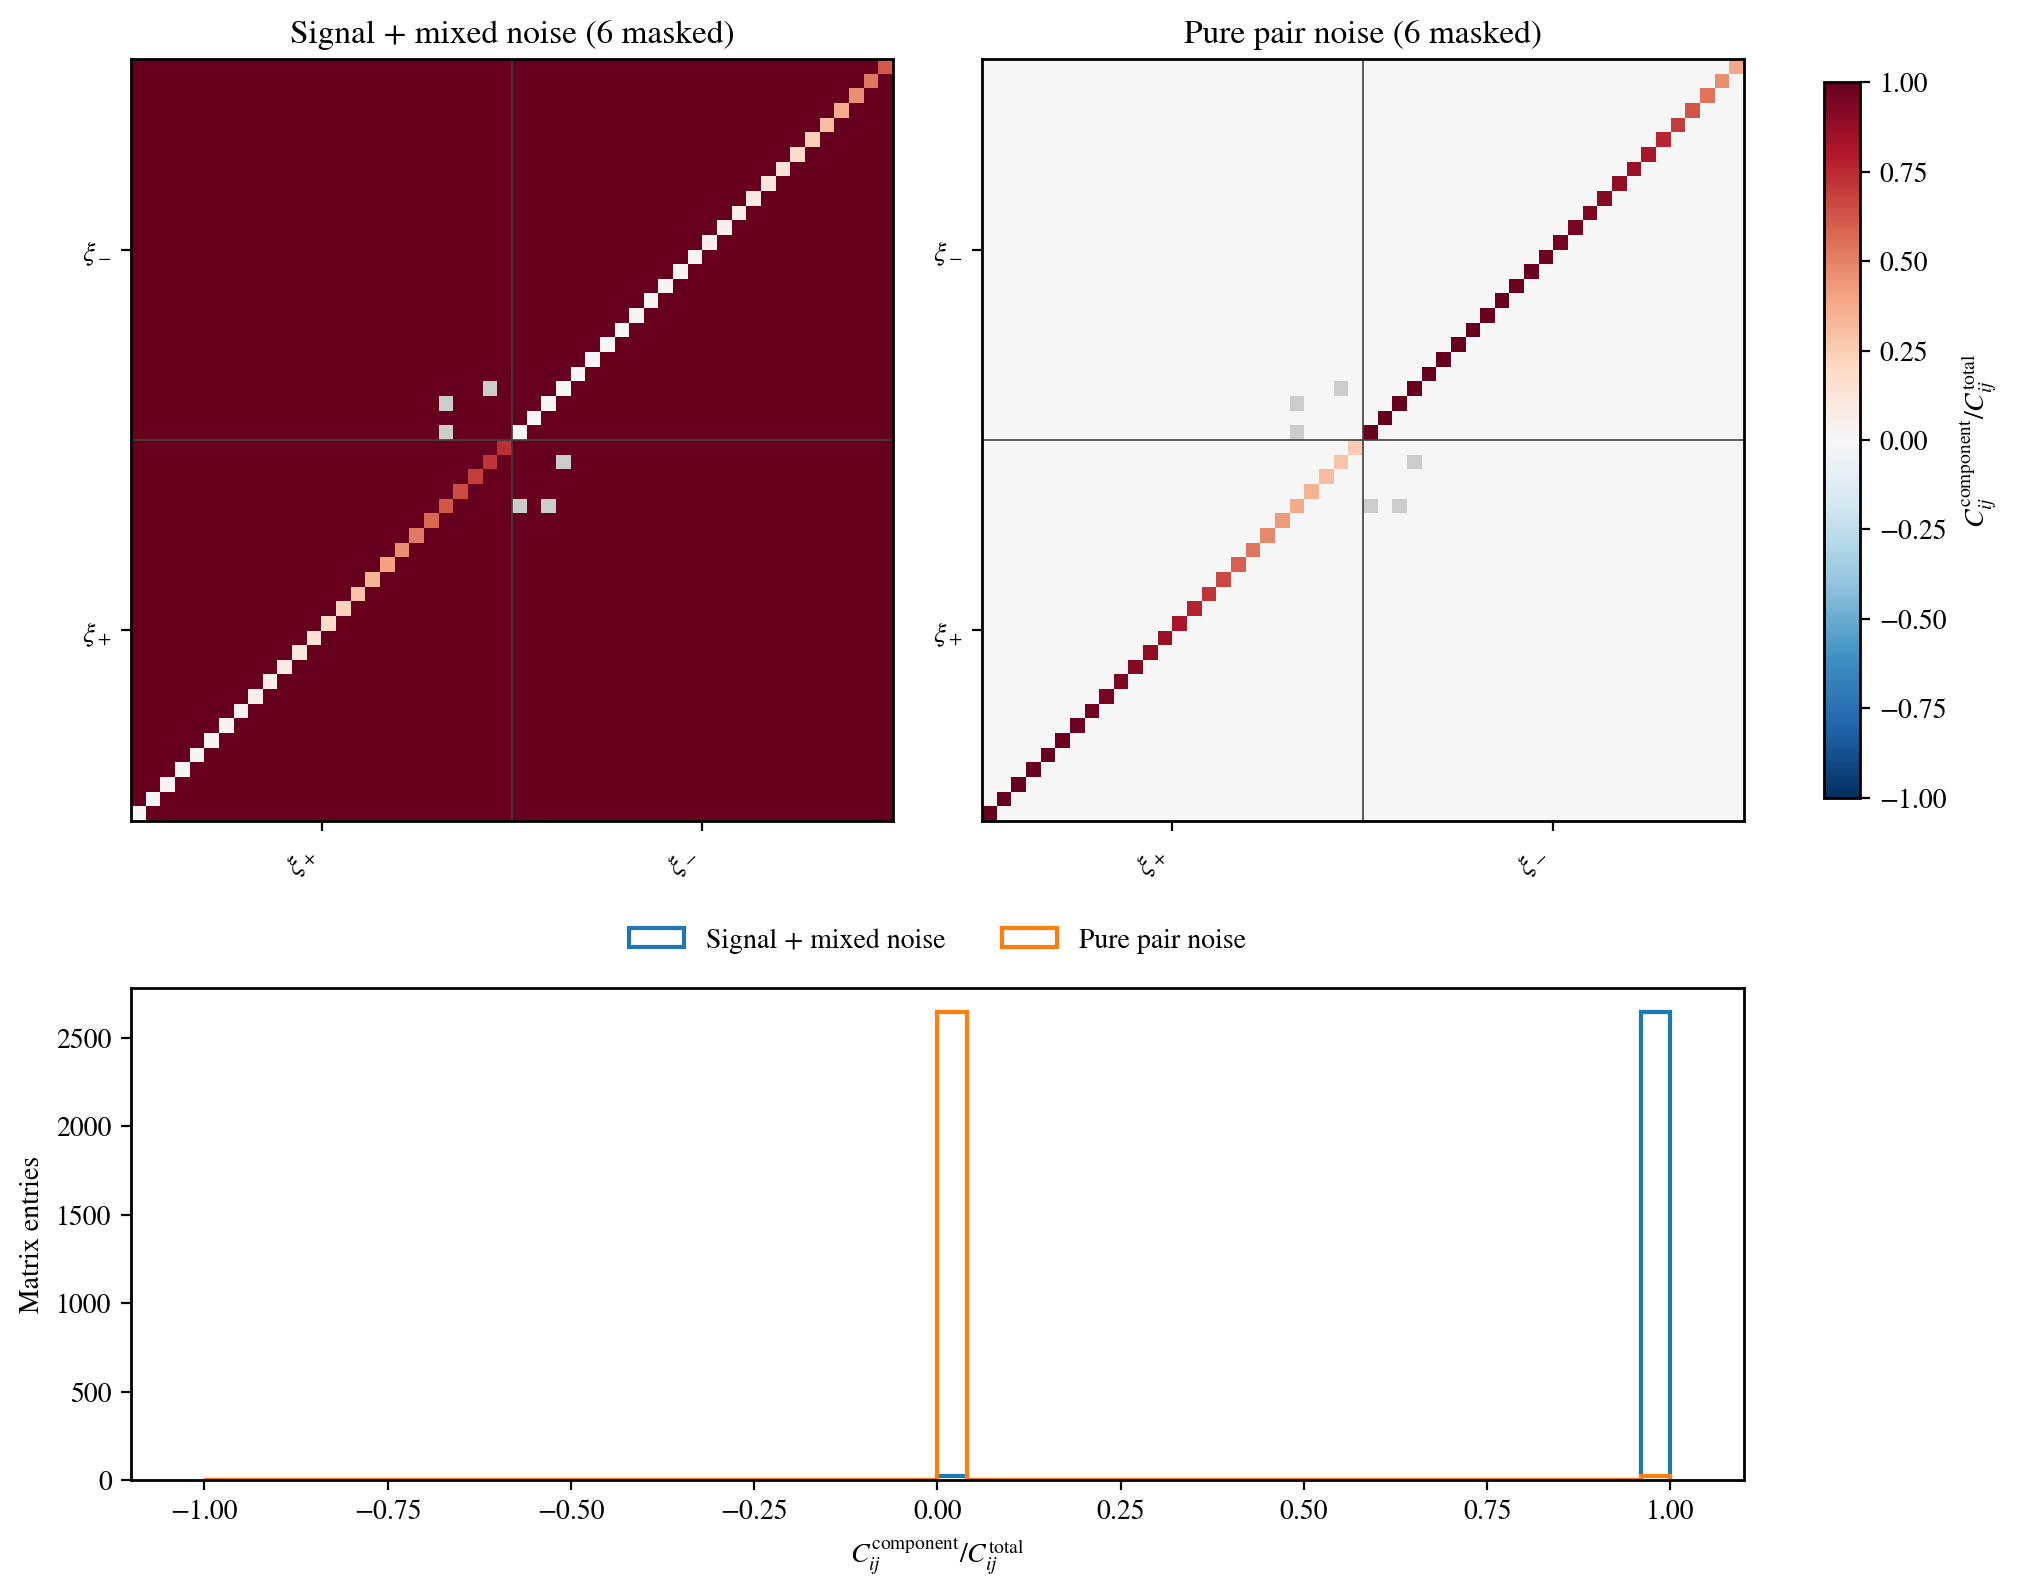

In [4]:
ntheta = len(result["theta_arcmin"])
block_sizes = [ntheta, ntheta]
block_labels = [r"$\xi_+$", r"$\xi_-$"]
pcov.plot_correlation(
    covariance=result["gaussian"],
    covariance_ref=reference["gaussian"],
    block_sizes=block_sizes,
    block_labels=block_labels,
    labels=(f"Boost {settings['accuracy_boost']}", f"Boost {reference_boost}"),
)
pcov.plot_covariance_components(
    total=reference["gaussian"],
    components={
        "Signal + mixed noise": reference["signal_mixed"],
        "Pure pair noise": reference["pure_noise"],
    },
    block_sizes=block_sizes,
    block_labels=block_labels,
    normalization="element",
)


## Error bars and changes with refinement

These panels show $\sqrt{C_{ii}}$ and its percent change, separately for
$\xi_+$ and $\xi_-$. A small diagonal change alone cannot guarantee accurate
parameter errors; the mode diagnostic above also checks coupled directions.
The plotting functions take NumPy arrays, so they work unchanged with other
survey projects or matrices assembled from several Python processes.


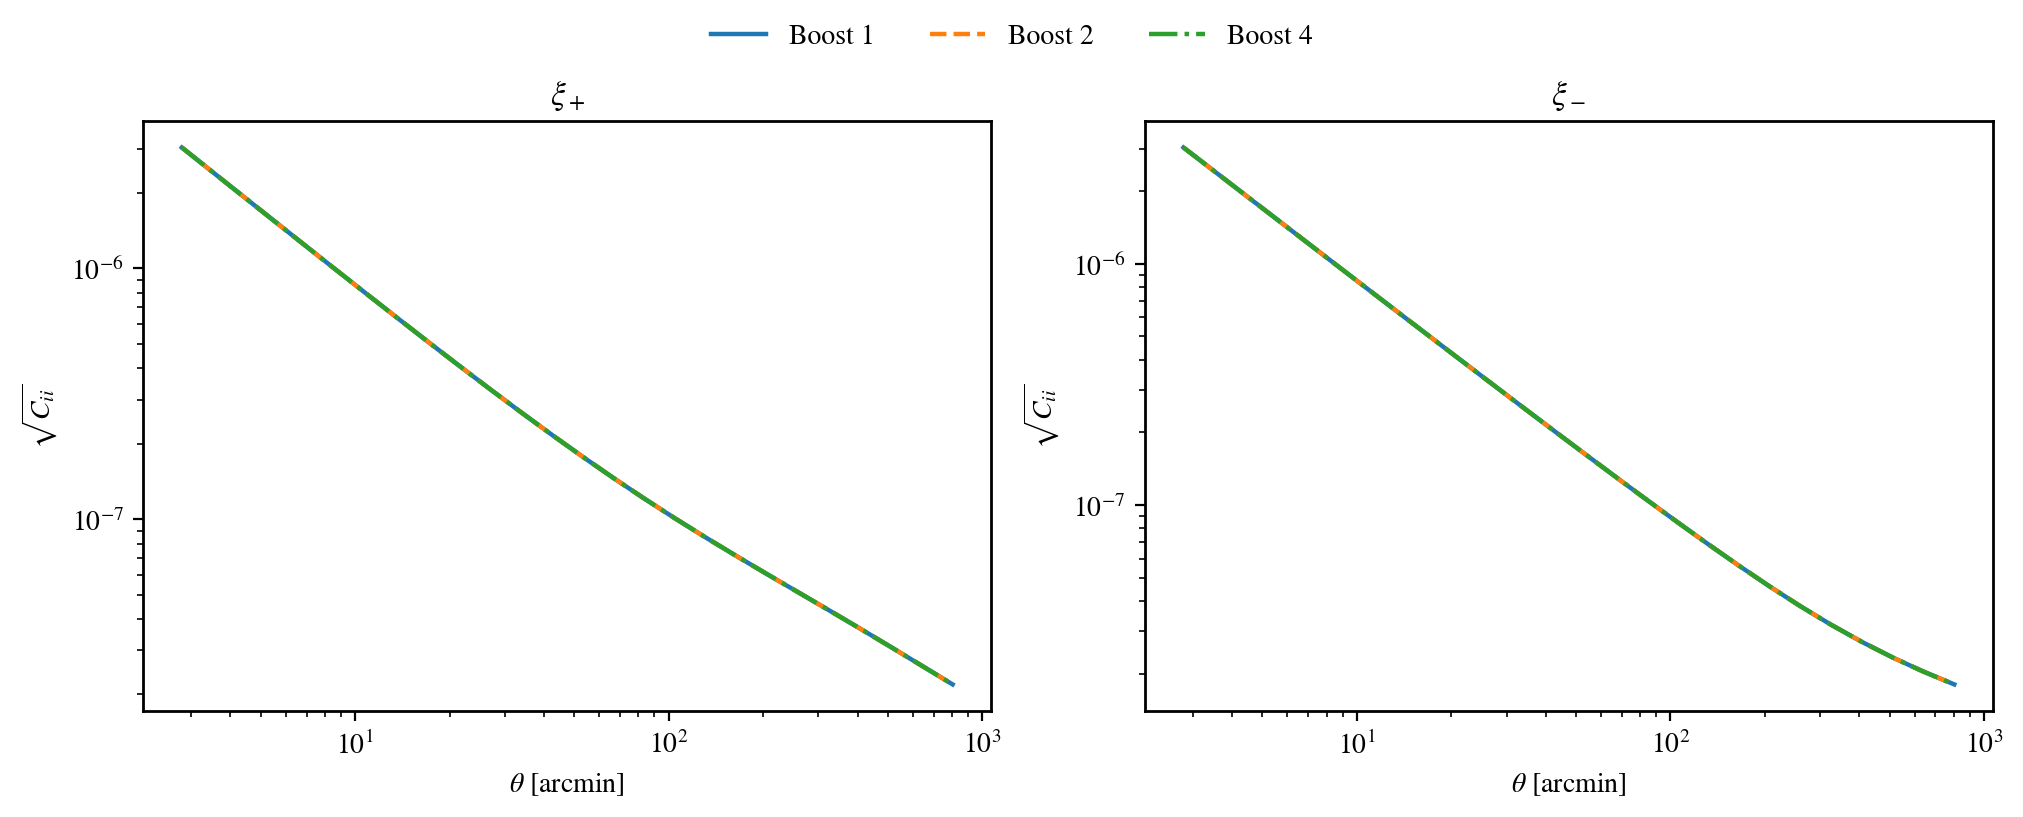

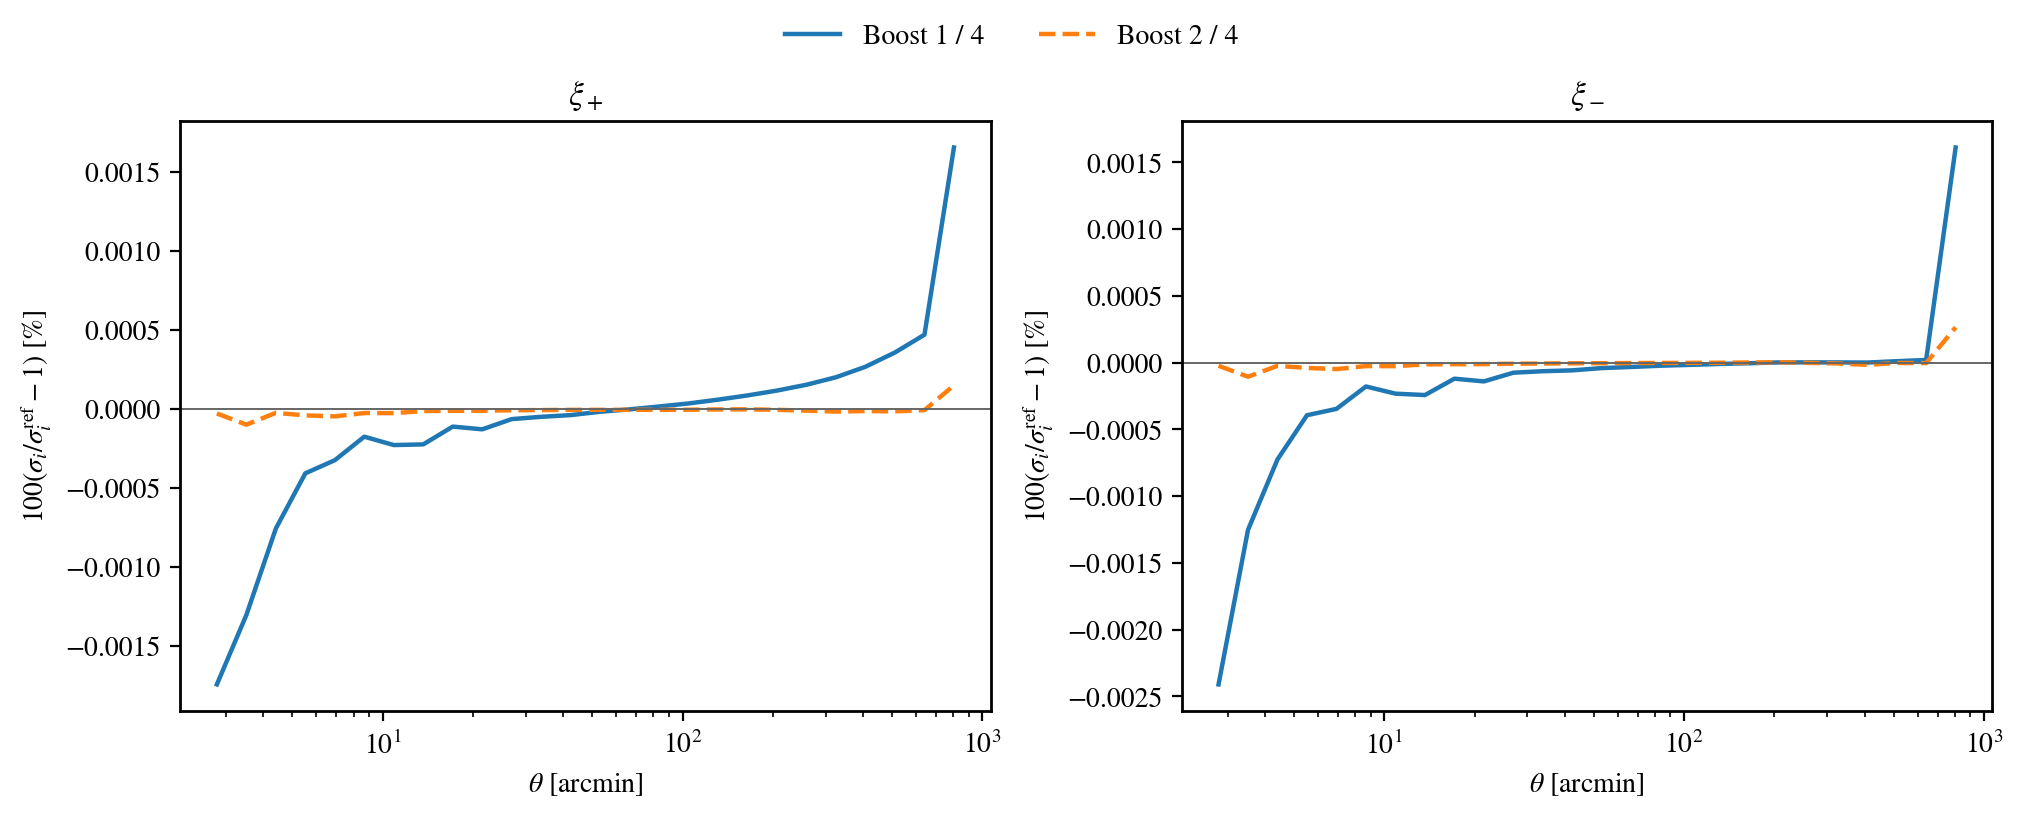

In [5]:
curves = {}
for boost in boosts:
    curves[f"Boost {boost}"] = results_by_boost[boost]["gaussian"]
pcov.plot_covariance_diagonal(
    theta_arcmin=result["theta_arcmin"],
    covariances=curves,
    panel_labels=block_labels,
)

# Exclude the reference's identically zero curve from the difference panel.
changes = {}
for boost in boosts[:-1]:
    changes[f"Boost {boost} / {reference_boost}"] = curves[f"Boost {boost}"]
pcov.plot_covariance_diagonal(
    theta_arcmin=result["theta_arcmin"],
    covariances=changes,
    panel_labels=block_labels,
    covariance_ref=reference["gaussian"],
)


## Where the covariance changes with the boost

Each panel below is $100(C_b-C_4)_{ij}/\sqrt{(C_4)_{ii}(C_4)_{jj}}$ in percent, for boost
$b=1$ or $2$. A common signed color scale makes the two resolutions
comparable. Diagonal normalization remains finite when a cross-covariance
entry is zero, and reveals changes in the $\xi_+$--$\xi_-$ block as well as
the auto blocks. The histogram shows the distribution of those changes;
the variance-ratio table above tests their combined effect on matrix modes.


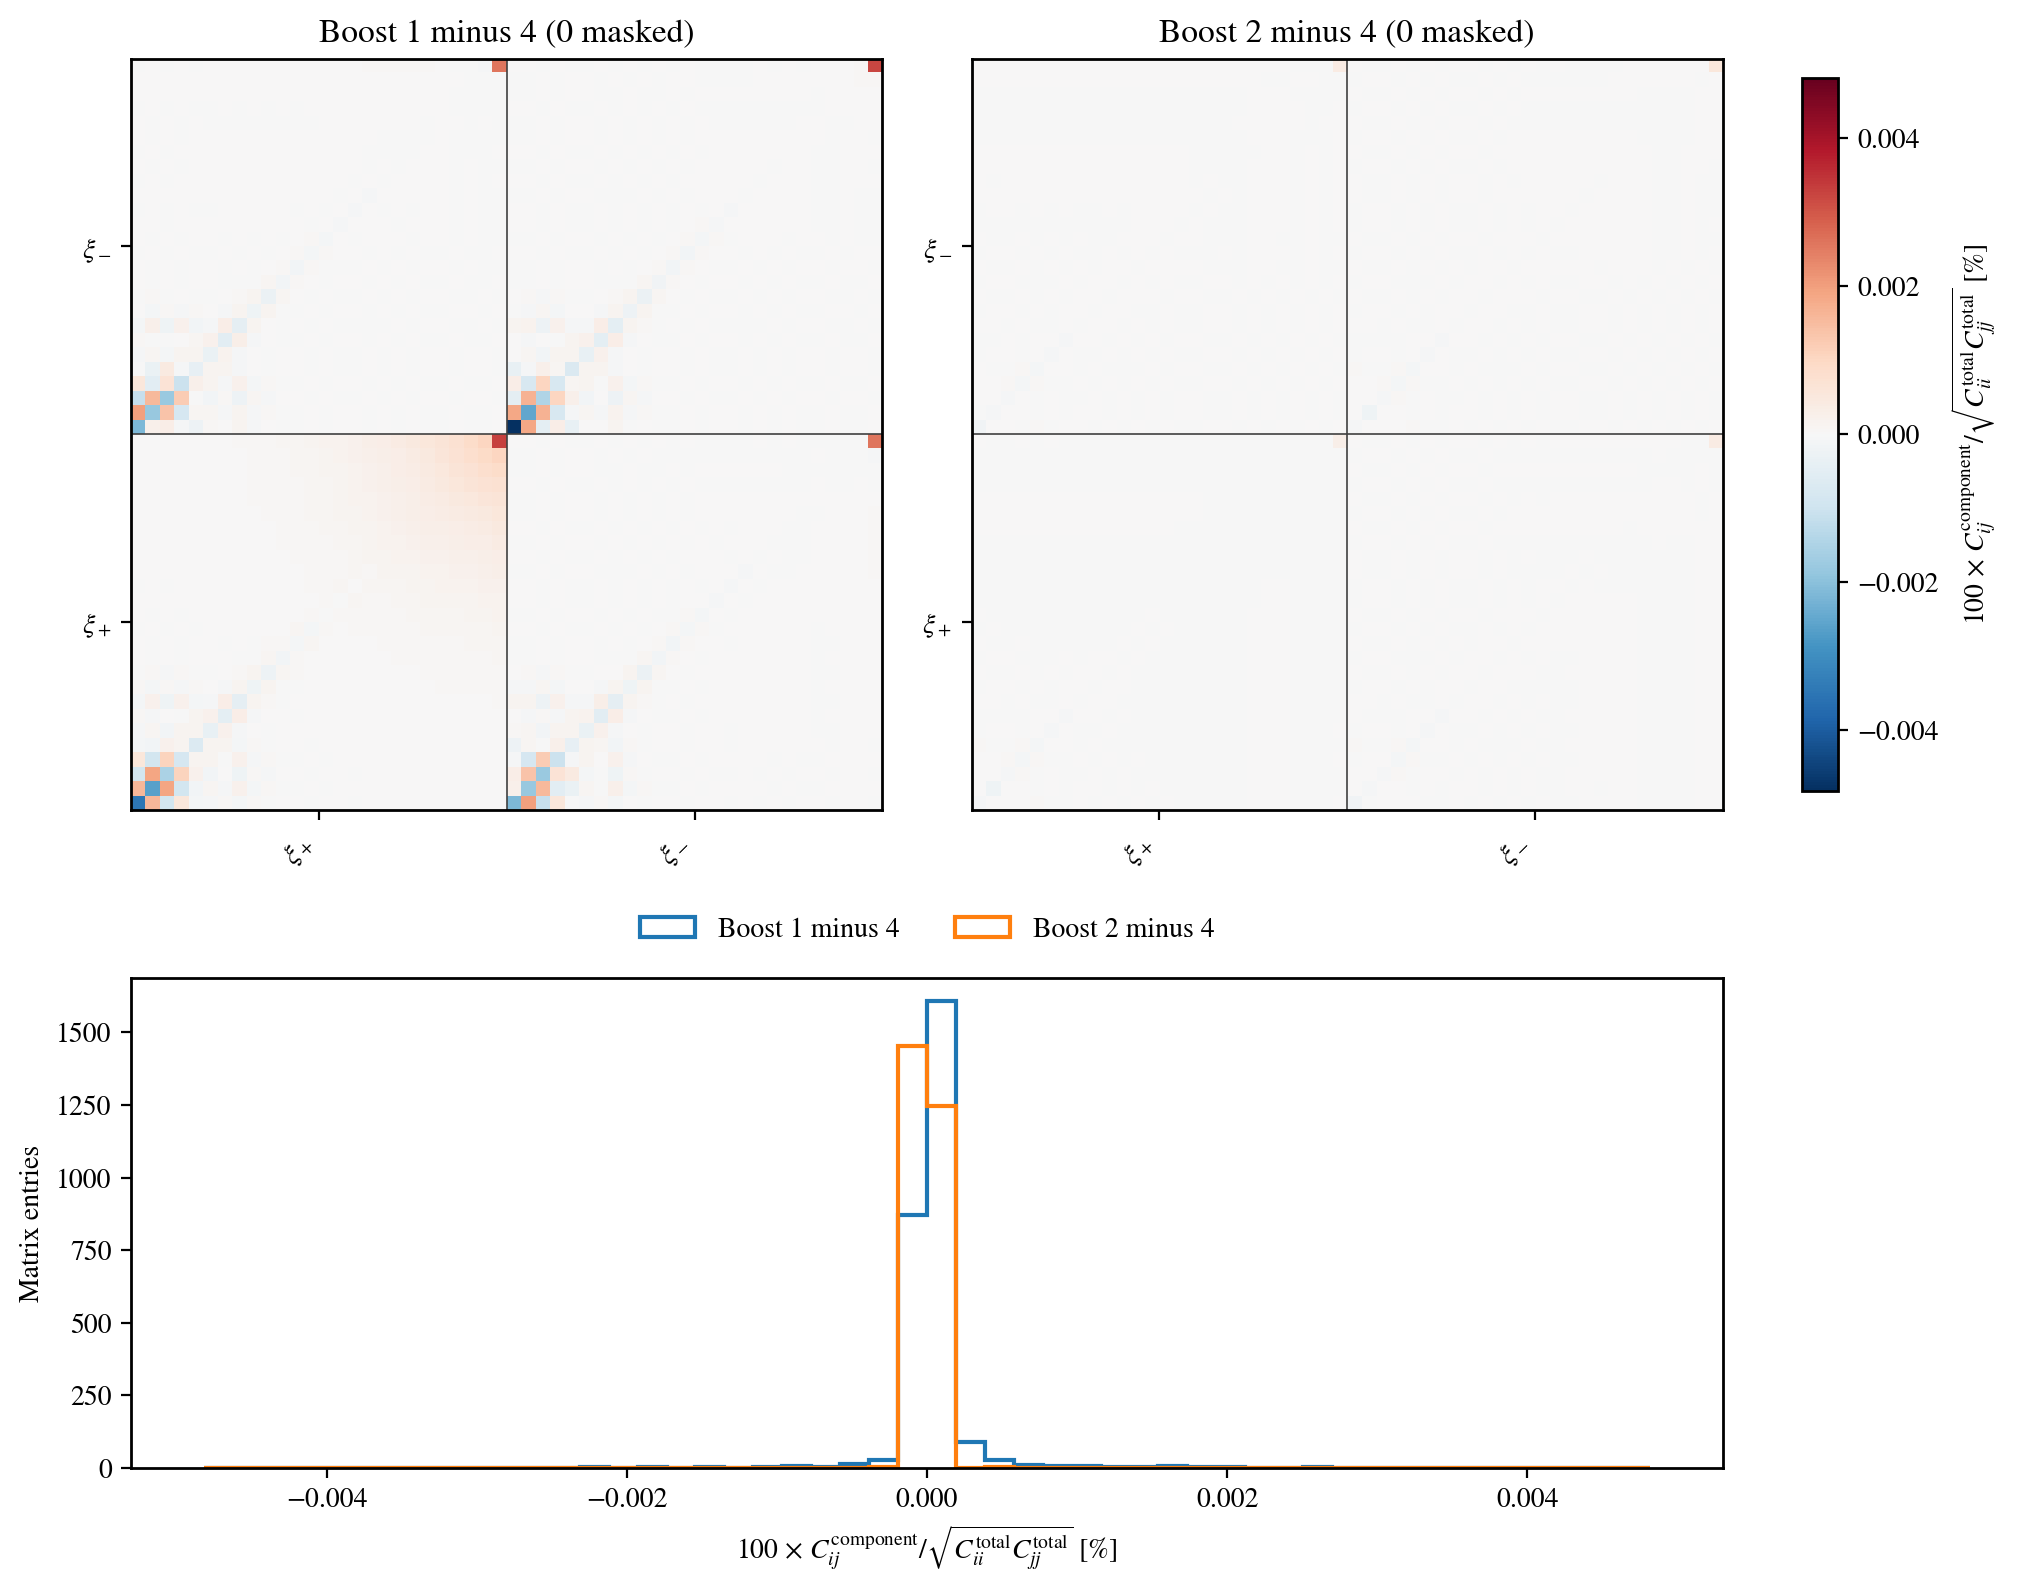

In [6]:
differences = {}
for boost in boosts[:-1]:
    differences[f"Boost {boost} minus {reference_boost}"] = (
        results_by_boost[boost]["gaussian"]-reference["gaussian"]
    )
pcov.plot_covariance_components(
    total=reference["gaussian"],
    components=differences,
    block_sizes=block_sizes,
    block_labels=block_labels,
    normalization="diagonal",
    percent=True,
)


## Reuse and next components

`cov.gaussian_block` accepts supplied spectra, field IDs and rectangular
operators. `cov.realspace_block` adds exact pair noise for common angular
bins. Keep **all** crossed spectra in the input, even if a crossed pair is
excluded from the measured data vector.

For non-Gaussian development, `cov.halo_power_response` and
`cov.halo_trispectrum` prepare the covariance-owned C components; their
current combined matter prescription requires massless neutrinos.
`DenseLogTable` constructs a dense table by cubic interpolation once, then
answers each fixed-physical-wavenumber query with two linear reads.

SSC must project common responses with positive radial weights, including
cross-lens blocks. Removing those blocks can create negative eigenvalues.
The complete G+SSC+cNG survey generator and its FoM convergence remain a
separate validation step. The physics and C-file guide are in the
[core covariance README](../../external_modules/code/cosmolike_core/cosmolike/covariances/README.md).
